In [248]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
from scipy.ndimage import convolve, generate_binary_structure

# Note
Most of this notebook was created with reference to the following sources:
- https://www.youtube.com/watch?v=K--1hlv9yv0
- https://github.com/lukepolson/youtube_channel/blob/main/Python%20Metaphysics%20Series/vid14.ipynb

The reference notebook was adapted to accommodate Hamiltonians with external magnetisation, etc.

# Introduction

A system in thermal equilibrium with a temperature bath. Probability $p_\mu$ of being in state $\mu$ with energy $E_\mu$ is

 $$p_\mu = \frac{1}{Z} e^{-\beta E_\mu} $$
 
where $Z = \sum_\mu e^{-\beta E_\mu}$ is the **partition function**. At equilbrium, the following must be true

$$\sum_\nu p_\mu P(\mu \to \nu) = \sum_\nu p_\nu P(\nu \to \mu)$$

where $P(\mu \to \nu)$ is the probability of going from state $\mu$ to $\nu$. For our numerical methods, this is difficult to enforce, but we can make it be true be setting the **detailed balance condition**

$$p_\mu P(\mu \to \nu) =p_\nu P(\nu \to \mu)$$

# Ising Model

The total energy is

$$E_\mu = -J\sum_{<i,j>}\sigma_i \sigma_j - h\sum_i\sigma_i$$

where $\sigma_i$ is the spin of a single particle in the lattice (either -1 or 1) and the sum over $<i,j>$ means summing over nearest neighbours for all points in the lattice. $\mu$ corresponds to a particular configuration of the spins. Now, satisfying detailed balance

$$\frac{P(\mu \to \nu)}{P(\nu \to \mu)} = \frac{p_\nu}{p_\mu} = e^{-\beta (E_\nu-E_\mu)}$$

# Metropolis Algorithm

**The Idea**: Want to find the equilibrium state $\mu$ in the magnet at a particular temperature $\beta$ (how many $\sigma_i$s are +1 and how many are -1). We'll start with a random lattice of spins, some pointing up and some pointing down, and make it dance around using the equation above until it fixes itself into equilibrium

1. Call the current state $\mu$. 
2. Pick a random particle on the lattice and flip the spin sign. Call the state $\nu$. We want to find the probability that $P(\mu \to \nu)$ that we'll accept this new state
3. * If $E_\nu > E_\mu$ then set $P(\nu \to \mu) = 1$ and thus by the detailed balance equation $P(\mu \to \nu) = e^{-\beta (E_\nu-E_\mu)}$. 
    * if $E_\mu > E_\nu$ then set $P(\mu \to \nu) = 1$. Still satisfies detailed balance!
4. Change to state $\nu$ (i.e. flip the spin of the particle) with the probabilities outlined above. 
5. Go back to step 1. Repeat the whole thing many many times and eventually you'll settle into the equilibrium distribution. 

Thus the only thing that needs to be evaluated is $$-\beta(E_\nu - E_\mu) = -2\beta J \sigma_i\left(\sum_{k=1}^4 \sigma_k+H\right)$$ where $i$ is the spin being flipped and $\sigma_k$ are the four nearest neighbours to that spin (two dimensions). On the boundaries, sometimes things might have less than 4 neighbours

# Dimensionless approach
To keep the whole simulation in terms of dimensionless quantities, the following conventions are used.

The Hamiltonian is measured in units of $J$,

$$\tilde E = -\sum_{<i,j>}\sigma_i\sigma_j - H \sum_i \sigma_i$$

where $\tilde E = E/J$ and $H=h/J$. As a result of this convention, the Metropolis factor becomes

$$e^{-\beta\Delta E} = e^{-\beta J \Delta\tilde E}$$

In [249]:
# controlled variables

N = 50 # size of square lattice
ratio = 0.5 # ratio of positive to negative spins

# metropolis parameters
H = 0.0 # H = h/J
BJ = 1 

# number of time steps to run the algorithm
steps = 500000

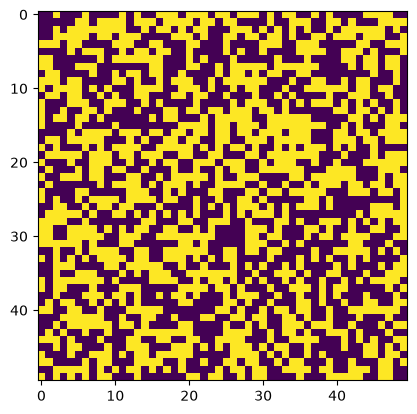

In [250]:
# generate lattice of random spins
init_random = np.random.random((N,N))
lattice = np.zeros((N, N))
lattice[init_random<=ratio] = 1
lattice[init_random>ratio] = -1

# plot generated lattice
plt.imshow(lattice)
plt.show()

Compute the dimensionless energy $$\tilde E_\mu = -\sum_{<i,j>}\sigma_i \sigma_j - H\sum_i\sigma_i$$
The interaction terms can be efficiently computed using convolutions. 

In [251]:
def get_energy(lattice, H=0.0):
    # nearest neighbours summation
    kern = generate_binary_structure(2, 1) 
    kern[1][1] = False

    interaction = -lattice * convolve(lattice, kern, mode='constant', cval=0) 
    field = -H * lattice
    
    return interaction.sum() / 2 + field.sum()

In [252]:
get_energy(lattice)

np.float64(10.0)

In [253]:
# numba speeds up the iterations to almost C speed
@numba.njit 
def metropolis(lattice, steps, BJ, H, energy):

    # 1. call current state mu
    lattice = lattice.copy()
    net_spins = np.zeros(steps-1)
    net_energies = np.zeros(steps-1)

    for t in range(0, steps-1):

        # 2. pick random spins and flip it
        x = np.random.randint(0,N)
        y = np.random.randint(0,N)

        spin_i = lattice[x,y]
        spin_f = spin_i * -1 # proposed sign flip

        # compute change in energy
        E_i = -H * spin_i
        E_f = -H * spin_f
        if x>0:
            E_i += -spin_i*lattice[x-1,y]
            E_f += -spin_f*lattice[x-1,y]
        if x<N-1:
            E_i += -spin_i*lattice[x+1,y]
            E_f += -spin_f*lattice[x+1,y]
        if y>0:
            E_i += -spin_i*lattice[x,y-1]
            E_f += -spin_f*lattice[x,y-1]
        if y<N-1:
            E_i += -spin_i*lattice[x,y+1]
            E_f += -spin_f*lattice[x,y+1]

        # 3 / 4. change state with designated probabilities
        dE = E_f-E_i
        if dE <= 0:
            lattice[x, y] = spin_f
            energy += dE
        elif np.random.random() < np.exp(-BJ * dE):
            lattice[x, y] = spin_f
            energy += dE
            
        net_spins[t] = lattice.sum()
        net_energies[t] = energy
            
    return net_spins, net_energies

In [254]:
spins, energies = metropolis(lattice, steps, BJ, H, get_energy(lattice, H))

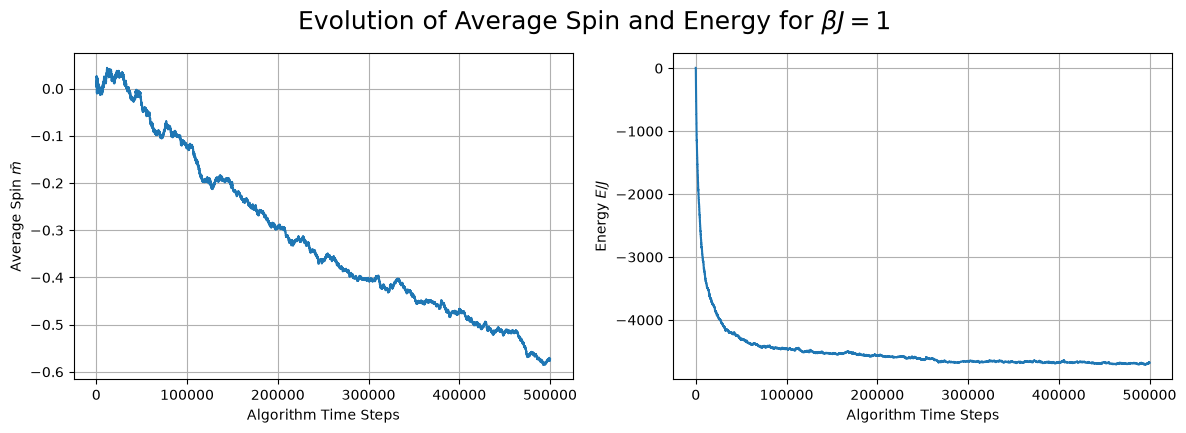

In [255]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
ax = axes[0]
ax.plot(spins/N**2)
ax.set_xlabel('Algorithm Time Steps')
ax.set_ylabel(r'Average Spin $\bar{m}$')
ax.grid()
ax = axes[1]
ax.plot(energies)
ax.set_xlabel('Algorithm Time Steps')
ax.set_ylabel(r'Energy $E/J$')
ax.grid()
fig.tight_layout()
fig.suptitle(rf'Evolution of Average Spin and Energy for $\beta J={BJ}$', y=1.07, size=18)
plt.show()